# AI labour supply vs. human cognitive labour

**Extrapolating the supply of AI cognitive labour as a share of human cognitive labour: 2026 -> 2031 -> 2036.**

Two transparent models, each projected forward with **Monte Carlo** uncertainty drawn as *fat-tail* bands.

| | What it measures | Numerator | Denominator |
|---|---|---|---|
| **Model 1 - Token throughput** | AI's share of *cognitive throughput* (volume) | AI tokens/sec | Human cognitive tokens/sec |
| **Model 2 - Economic value** | AI's share of the *labour market by value* | AI output priced at market \$/token (\$/yr) | White-collar wage bill (\$/yr) |

**AI token supply is anchored on the Epoch "compute crunch" curve** (the conservative 128k-ISL line:
~1e9 output tok/s across the full fleet in 2026, growing ~3.4x/yr), then multiplied by a realistic
**inference share (~10%)** of the fleet. This replaces an earlier bottom-up (stock x per-GPU)
estimate that ran ~10-28x hotter because it used a 35% inference fraction and a short-context
per-GPU throughput, and grew only with raw compute rather than Epoch's faster token-throughput trend.

**Everything lives in `parameters.csv`** - edit and re-run. Both models are *capacity / supply*
statements: token (or dollar) parity is an **upper bound** on substitution, not a measure of realised
job displacement.

## 1. Setup - load parameters and define the sampler

In [1]:
import csv, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

CSV = next((p for p in [Path("parameters.csv"), Path("tai_model/parameters.csv")] if p.exists()), None)
assert CSV is not None, "parameters.csv not found next to the notebook"
print("Using parameters from:", CSV.resolve())

def load_params(path):
    P = {}
    for r in csv.DictReader(open(path)):
        f = lambda x: float(x) if x not in ("", None) else None
        P[r["id"]] = dict(value=f(r["value"]), low=f(r["low"]), high=f(r["high"]),
                          dist=r["dist"], unit=r["unit"], parameter=r["parameter"], note=r["note"])
    return P

def sample(P, n, seed=0):
    rng = np.random.default_rng(seed); out = {}
    for k, v in P.items():
        d = v["dist"]
        if d == "point" or v["low"] is None or v["low"] == v["high"]:
            out[k] = np.full(n, v["value"])
        elif d == "uniform":
            out[k] = rng.uniform(v["low"], v["high"], n)
        elif d == "triangular":
            out[k] = rng.triangular(v["low"], v["value"], v["high"], n)
        elif d == "lognormal":           # value = median; low/high ~ P5/P95
            mu = math.log(v["value"]); sig = (math.log(v["high"]) - math.log(v["low"])) / (2 * 1.645)
            out[k] = rng.lognormal(mu, sig, n)
        else:
            out[k] = np.full(n, v["value"])
    return out

P = load_params(CSV)
central = {k: v["value"] for k, v in P.items()}
print(f"Loaded {len(P)} parameters.")


Using parameters from: /sessions/magical-intelligent-fermi/mnt/economics of AGI/tai_model/parameters.csv
Loaded 37 parameters.


## 2. The models

### Shared building blocks

**AI cognitive output** (tokens/sec) - anchored on the Epoch full-fleet token-throughput curve
(128k-ISL regime), grown at the Epoch rate, then scaled by the realistic inference share:

$$\text{AI}_{\text{tok/s}}(y) = \underbrace{\text{tput}_{2026}\times \text{tput\_growth}^{\,(y-2026)}}_{\text{Epoch full-fleet curve}}\;\times\; \underbrace{\text{inference\_share}}_{\sim 10\%}$$

`tput_growth` (~3.4x/yr) is **larger than raw compute growth (~3x)** because Epoch's curve also
captures inference-efficiency gains. `inference_share` (~10%) is the fraction of the fleet actually
serving inference, and conservatively also absorbs the slowdown from larger future models.

**Human cognitive output** (tokens/sec):

$$\text{H}_{\text{tok/s}}(y) = \text{workers}(y)\times \tfrac{\text{tok/min}}{60}\times \text{duty}$$

`labour_duty = 1.0` treats humans as always-on (conservative about AI's share); set ~0.23 for an
annual-average (≈2000 work-hrs/yr) comparison.

### Model 1 - Token throughput share
$$\text{share}_1(y)=\dfrac{\text{AI}_{\text{tok/s}}(y)}{\text{H}_{\text{tok/s}}(y)}$$

### Model 2 - Economic-value (wage) share
$$\text{share}_2(y)=\dfrac{\text{AI}_{\text{tok/s}}(y)\times \text{sec/yr}\times \text{price}(y)}{\text{workers}(y)\times \text{wage/worker}}$$

**The two models differ only by a price ratio.** $\text{share}_2 = \text{share}_1\times\dfrac{\text{AI \$/token}}{\text{human \$/token}}$,
where the human implied price = wage ÷ annual tokens per worker. With AI ≈ \$2/Mtok and a human
"token" ≈ \$57/Mtok, Model 2 ≈ Model 1 ÷ 28. That ~28x gap (a human cognitive token currently sells
for far more than an AI one) **is** the whole difference between the two.

In [2]:
YEARS = [2026, 2031, 2036]

def workers_at(s, year):
    return {2026: s["workers_2026"], 2031: s["workers_2031"], 2036: s["workers_2036"]}[year]

def ai_full_fleet_tok_per_sec(s, year):                 # Epoch curve, 100%-inference hypothetical
    return s["token_tput_2026"] * s["token_tput_growth"] ** (year - 2026)

def ai_tok_per_sec(s, year):                            # realistic: x inference share
    return ai_full_fleet_tok_per_sec(s, year) * s["inference_share"]

def human_tok_per_sec(s, year):
    return workers_at(s, year) * (s["human_tok_min"] / 60.0) * s["labour_duty"]

def blended_price_per_tok(s, year):
    blended_mkt = (s["price_in_mkt"] * s["io_ratio"] + s["price_out_mkt"]) / (s["io_ratio"] + 1)  # $/Mtok
    return (blended_mkt / 1e6) * s["price_decline_per_yr"] ** (year - 2026)                       # $/token

def model1_share(s, year):                              # token throughput
    return ai_tok_per_sec(s, year) / human_tok_per_sec(s, year)

def model2_share(s, year):                              # economic value / wage share
    ai_value  = ai_tok_per_sec(s, year) * s["seconds_per_year"] * blended_price_per_tok(s, year)
    wage_bill = workers_at(s, year) * s["wage_per_worker"]
    return ai_value / wage_bill

MODELS = {"Model 1 - Token throughput share": model1_share,
          "Model 2 - Economic-value (wage) share": model2_share}


## 3. Central estimates

In [3]:
def pct(x): return f"{x*100:,.2f}%"

print(f"{'':<40}{'2026':>12}{'2031':>14}{'2036':>14}")
print("-"*80)
for name, fn in MODELS.items():
    print(f"{name:<40}" + "".join(f"{pct(fn(central,y)):>14}" for y in YEARS))

# implied prices and the Model2/Model1 ratio (the conceptual gap between the two models)
bm = (central["price_in_mkt"]*central["io_ratio"]+central["price_out_mkt"])/(central["io_ratio"]+1)
tok_per_worker_yr = (central["human_tok_min"]/60.0)*central["labour_duty"]*central["seconds_per_year"]
human_price_Mtok  = central["wage_per_worker"]/tok_per_worker_yr*1e6
print(f"\nAI blended price        ~ ${bm:5.2f}/Mtok")
print(f"Human implied price     ~ ${human_price_Mtok:6.1f}/Mtok  (= wage / annual tokens per worker)")
print(f"=> Model 2 / Model 1    ~ {bm/human_price_Mtok:6.3f}  (x{human_price_Mtok/bm:,.0f} cheaper per AI token)")

print()
for y in YEARS:
    print(f"{y}: full-fleet = {ai_full_fleet_tok_per_sec(central,y):.3e} tok/s | "
          f"AI (x{central['inference_share']:.0%} inf) = {ai_tok_per_sec(central,y):.3e} tok/s | "
          f"Human = {human_tok_per_sec(central,y):.3e} tok/s")


                                                2026          2031          2036
--------------------------------------------------------------------------------
Model 1 - Token throughput share                 0.44%       181.74%    77,414.17%
Model 2 - Economic-value (wage) share            0.02%         6.34%     2,702.42%

AI blended price        ~ $ 1.99/Mtok
Human implied price     ~ $  57.1/Mtok  (= wage / annual tokens per worker)
=> Model 2 / Model 1    ~  0.035  (x29 cheaper per AI token)

2026: full-fleet = 1.000e+09 tok/s | AI (x10% inf) = 1.000e+08 tok/s | Human = 2.250e+10 tok/s
2031: full-fleet = 4.544e+11 tok/s | AI (x10% inf) = 4.544e+10 tok/s | Human = 2.500e+10 tok/s
2036: full-fleet = 2.064e+14 tok/s | AI (x10% inf) = 2.064e+13 tok/s | Human = 2.667e+10 tok/s


## 4. Monte Carlo

`N` joint draws across all distributions; we report the 5/25/50/75/95th percentiles. The dominant
spread drivers are the Epoch token-throughput growth (3-4x/yr), the 2026 throughput anchor, and the
inference share - compounded over 5 and 10 years.

In [4]:
N = 200_000
draws = sample(P, N, seed=20260615)
PCTS = [5, 25, 50, 75, 95]
def bands(fn): return {y: np.percentile(fn(draws, y), PCTS) for y in YEARS}
band_results = {name: bands(fn) for name, fn in MODELS.items()}

for name, b in band_results.items():
    print(f"\n{name}   (P5 / P25 / P50 / P75 / P95)")
    for y in YEARS:
        p = b[y] * 100
        print(f"  {y}:  {p[0]:>9.2f}% | {p[1]:>9.2f}% | {p[2]:>9.2f}% | {p[3]:>9.2f}% | {p[4]:>9.2f}%")



Model 1 - Token throughput share   (P5 / P25 / P50 / P75 / P95)
  2026:       0.12% |      0.28% |      0.52% |      0.96% |      2.32%
  2031:      52.52% |    132.64% |    252.48% |    484.43% |   1226.48%
  2036:   18304.00% |  51620.53% | 107620.41% | 225373.99% | 641694.85%

Model 2 - Economic-value (wage) share   (P5 / P25 / P50 / P75 / P95)
  2026:       0.00% |      0.01% |      0.01% |      0.02% |      0.06%
  2031:       0.69% |      1.92% |      3.86% |      7.72% |     20.62%
  2036:      96.05% |    388.79% |    986.24% |   2409.76% |   8112.10%


## 5. The plots

Solid line = Monte Carlo **median**; dark band = **P25-P75**; light band = **P5-P95** (fat tails).
Dashed grey line = **parity (100%)**. Log y-axis.

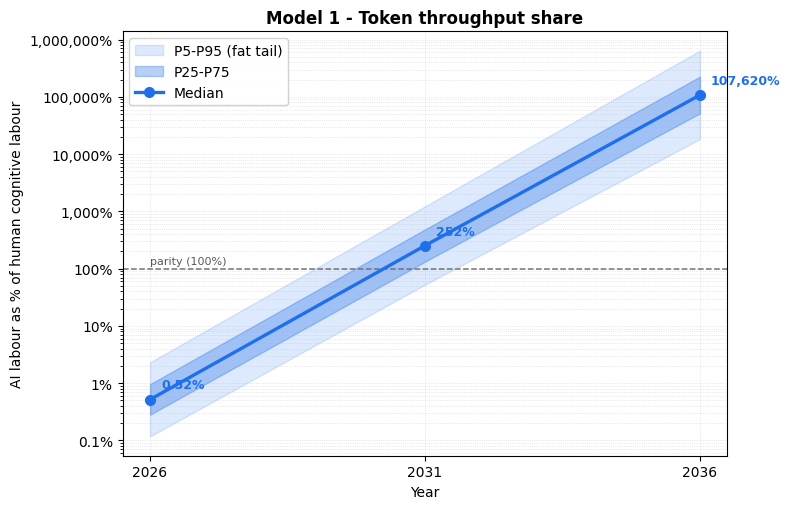

In [5]:
def pct_fmt(v, _): return f"{v:,.0f}%" if v >= 1 else f"{v:g}%"

def fan_plot(bands, title, color, fname):
    ys  = np.array(YEARS)
    arr = np.array([bands[y] for y in YEARS]) * 100
    p5, p25, p50, p75, p95 = arr.T
    fig, ax = plt.subplots(figsize=(8, 5.2))
    ax.fill_between(ys, p5,  p95, color=color, alpha=0.15, label="P5-P95 (fat tail)")
    ax.fill_between(ys, p25, p75, color=color, alpha=0.32, label="P25-P75")
    ax.plot(ys, p50, color=color, lw=2.4, marker="o", ms=7, label="Median", zorder=5)
    ax.axhline(100, ls="--", lw=1.1, color="0.45")
    ax.text(ys[0], 112, "parity (100%)", color="0.35", fontsize=8, va="bottom")
    for x, m in zip(ys, p50):
        ax.annotate(f"{m:,.0f}%" if m >= 10 else f"{m:.2f}%", (x, m),
                    textcoords="offset points", xytext=(8, 8), fontsize=9, fontweight="bold", color=color)
    ax.set_yscale("log"); ax.set_xticks(YEARS)
    ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
    ax.set_xlabel("Year"); ax.set_ylabel("AI labour as % of human cognitive labour")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, which="both", ls=":", lw=0.5, alpha=0.5)
    ax.legend(loc="upper left", framealpha=0.9)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

names = list(band_results)
fan_plot(band_results[names[0]], names[0], "#1f6feb", "fig_model1_token_share.png")


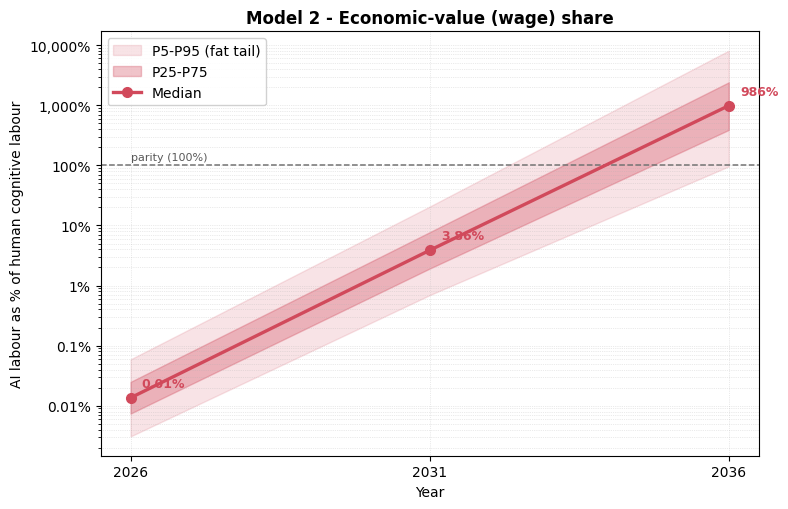

In [6]:
fan_plot(band_results[names[1]], names[1], "#d1495b", "fig_model2_value_share.png")

## 6. What drives the answer (sensitivity)

Spearman rank-correlation of each input against the **2031** output.

In [7]:
from scipy.stats import spearmanr
def sensitivity(fn, year=2031, top=8):
    y = fn(draws, year); rows=[]
    for k, x in draws.items():
        if np.ptp(x) == 0: continue
        rows.append((k, spearmanr(x, y).correlation))
    rows.sort(key=lambda r: -abs(r[1])); return rows[:top]
for name, fn in MODELS.items():
    print(f"\n{name}  - top drivers of the 2031 value (Spearman rho):")
    for k, rho in sensitivity(fn):
        print(f"   {k:<24} {rho:+.3f}   ({P[k]['parameter']})")



Model 1 - Token throughput share  - top drivers of the 2031 value (Spearman rho):


   token_tput_2026          +0.848   (Full-fleet output throughput 2026 (128k ISL))
   token_tput_growth        +0.297   (Token-throughput growth rate)
   inference_share          +0.278   (Realistic fraction of fleet doing inference (labour models))
   human_tok_min            -0.261   (Human cognition rate)
   workers_2031             -0.099   (White-collar workers 2031)
   stock_2026               +0.005   (Global compute stock 2026)
   epoch_token_capacity_2031 +0.005   (Token capacity 2031 (full-fleet inference))
   workers_2026             +0.003   (White-collar workers 2026)

Model 2 - Economic-value (wage) share  - top drivers of the 2031 value (Spearman rho):


   token_tput_2026          +0.783   (Full-fleet output throughput 2026 (128k ISL))
   price_decline_per_yr     +0.375   (Annual $/token price multiplier)
   token_tput_growth        +0.275   (Token-throughput growth rate)
   inference_share          +0.258   (Realistic fraction of fleet doing inference (labour models))
   wage_per_worker          -0.177   (Avg white-collar annual wage)
   workers_2031             -0.093   (White-collar workers 2031)
   price_in_mkt             +0.091   (Input price (3rd-party median))
   price_out_mkt            +0.056   (Output price (3rd-party median))


## 7. Reading the results - caveats and how to tune

**This build mirrors the Epoch-based assumptions.** AI token supply = Epoch 128k full-fleet curve
(~1e9 tok/s in 2026, ~3.4x/yr) x ~10% inference share. Model 1's central 2026 figure (~0.4%) and
2031 (~180%, with the 3-4x growth range reaching ~400% at the top) line up with the draft's
"0.2-20% -> 4-400%" once the ISL-regime and human-rate uncertainty is included.

**Why Model 2 sits ~28x below Model 1.** Identical numerator-growth, but Model 2 prices AI tokens at
the market rate (~\$2/Mtok) against a human "token" worth ~\$57/Mtok (wage ÷ annual output). If you
believe AI token prices will rise toward human-equivalent value (less commoditised, higher-value
work), Model 2 moves toward Model 1; if they fall, it drops further (see `price_decline_per_yr`).

**Levers in `parameters.csv`:**

- `token_tput_2026`, `token_tput_growth` - the Epoch anchor and its growth (the dominant inputs).
- `inference_share` - 10% default; raise it and both models scale up linearly.
- `labour_duty` - 1.0 = always-on humans (conservative); ~0.23 quadruples the AI share.
- `price_decline_per_yr` - <1 applies token-price deflation to Model 2 only.
- `wage_per_worker`, `human_tok_min`, `workers_*` - the human-side denominators.

**Caveats.** Post-2031 values are capacity upper bounds and the bands are very wide *by construction*
(3-4x/yr compounded). Token parity != job replacement. The two models are not statistically
independent (shared AI-output term), so their agreement is structural, not corroboration.